In [1]:
# Import Libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [6]:
# Loading dataset

In [7]:
df = pd.read_csv("advertising.csv")

In [8]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [9]:
df.shape

(200, 4)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [11]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [12]:
# Check Missing Values

In [13]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [14]:
# Showing how TV advertising affect Sales

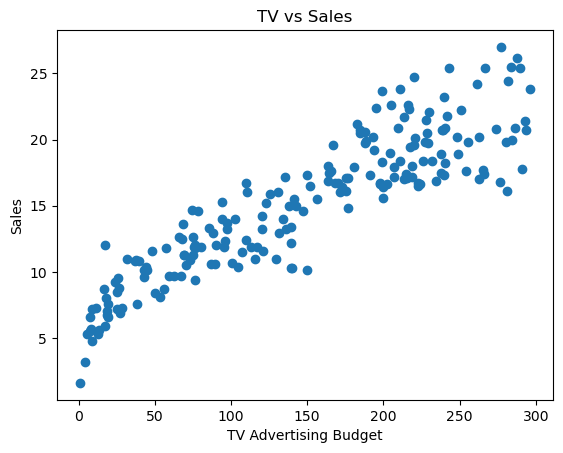

In [18]:
plt.figure()
plt.plot(df["TV"], df["Sales"], 'o')
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV vs Sales")
plt.show()

In [19]:
# Showing relationship between radio ads and sales

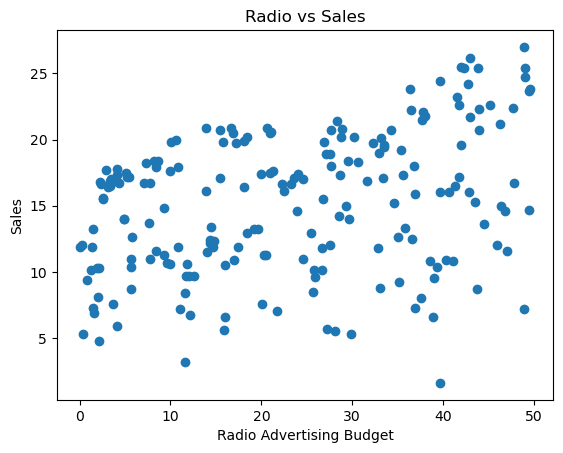

In [20]:
plt.figure()
plt.scatter(df["Radio"], df["Sales"])
plt.xlabel("Radio Advertising Budget")
plt.ylabel("Sales")
plt.title("Radio vs Sales")
plt.show()

In [21]:
# Help Understand distribution and variation

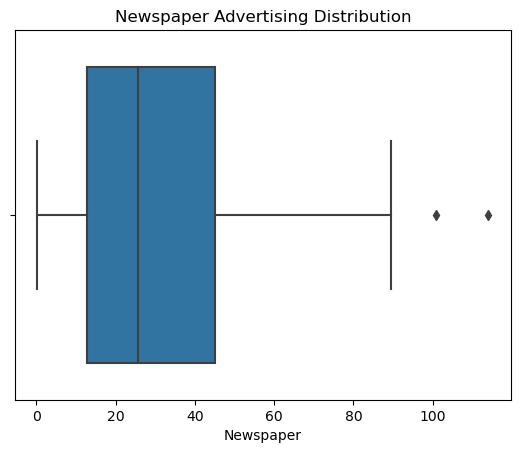

In [23]:
plt.figure()
sns.boxplot(x=df["Newspaper"])
plt.title("Newspaper Advertising Distribution")
plt.show()

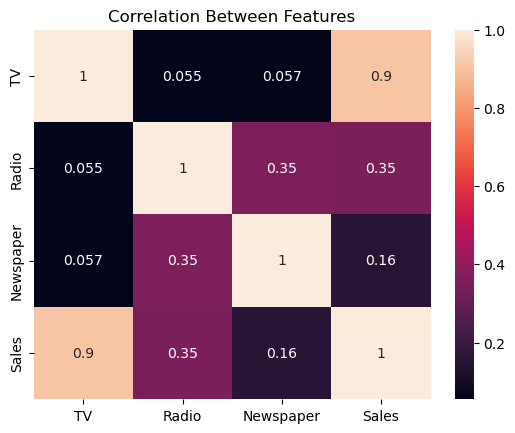

In [24]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Between Features")
plt.show()

In [25]:
# Selecting input features and target variables

In [28]:
features = ["TV", "Radio", "Newspaper"]
x = df[features]
y = df["Sales"]

In [31]:
scaler = StandardScaler()
x = scaler.fit_transform(x)

In [32]:
# Dividing data into training and testing sets

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)

In [34]:
# Training the model

In [35]:
model = RandomForestRegressor(n_estimators=120)
model.fit(x_train, y_train)

RandomForestRegressor(n_estimators=120)

In [36]:
# Predicting sales using test data 

In [37]:
predictions = model.predict(x_test)

In [38]:
# Evaluating The model

In [39]:
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("\nModel Performance:")
print("MAE (error):", mae)
print("R2 Score:", r2)


Model Performance:
MAE (error): 0.9056041666666651
R2 Score: 0.9577567645830671


In [40]:
# Comparing actual sales vs predicted sales

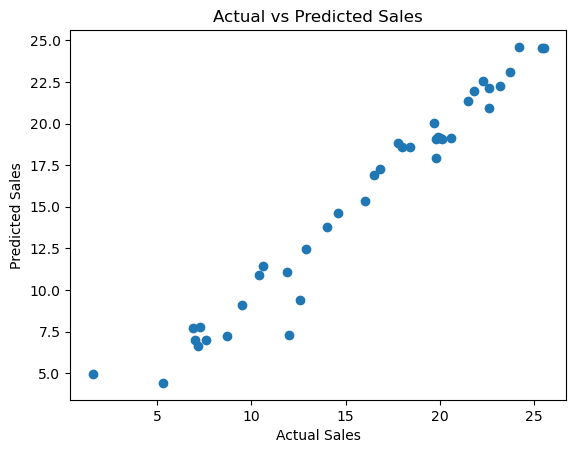

In [41]:
plt.figure()
plt.scatter(y_test, predictions)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()